In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


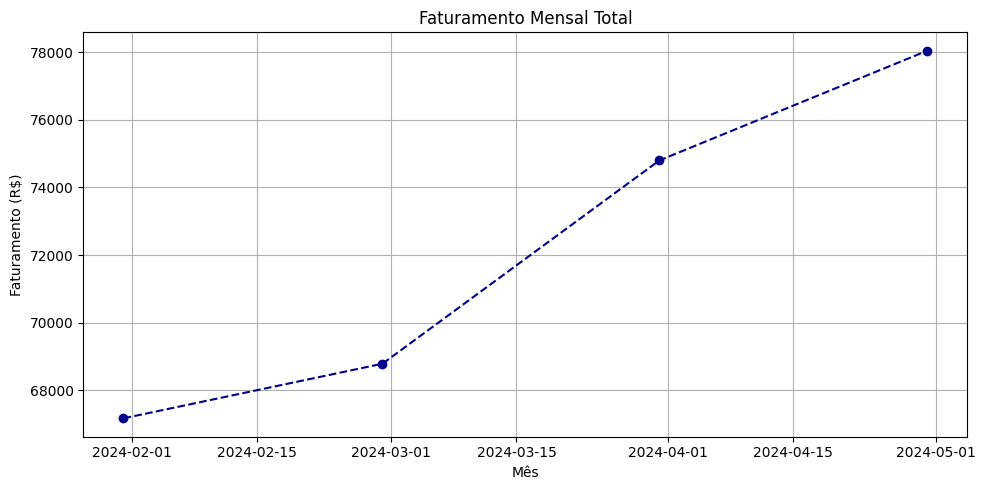

In [ ]:
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='darkblue'
)
ax.set_title('Faturamento Mensal Total')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True)
plt.tight_layout()
plt.show()

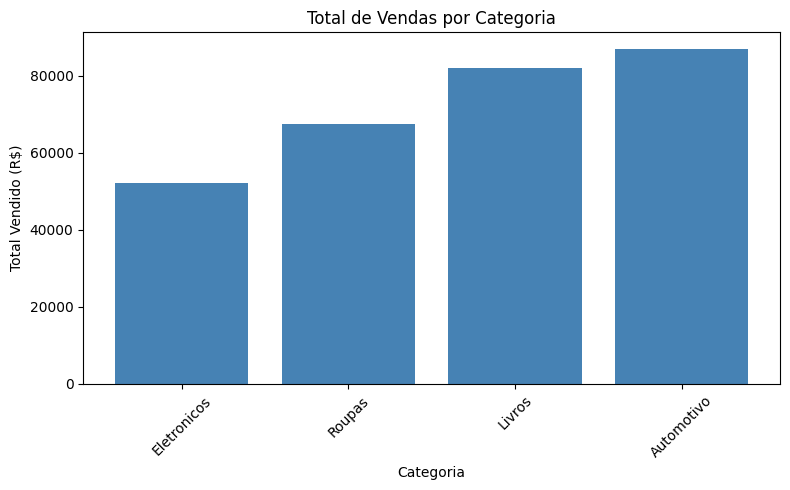

In [ ]:
vendas_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(vendas_categoria.index, vendas_categoria.values, color='steelblue')
ax.set_title('Total de Vendas por Categoria')
ax.set_xlabel('Categoria')
ax.set_ylabel('Total Vendido (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

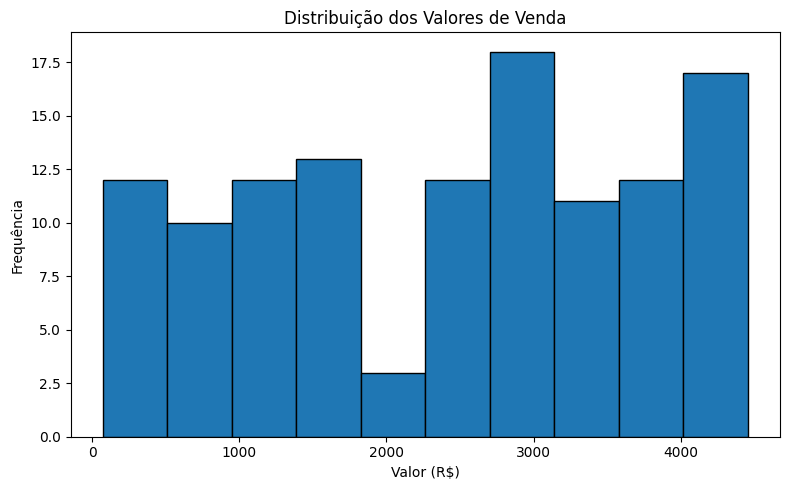

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['valor'], bins=10, edgecolor='black')
ax.set_title('Distribuição dos Valores de Venda')
ax.set_xlabel('Valor (R$)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

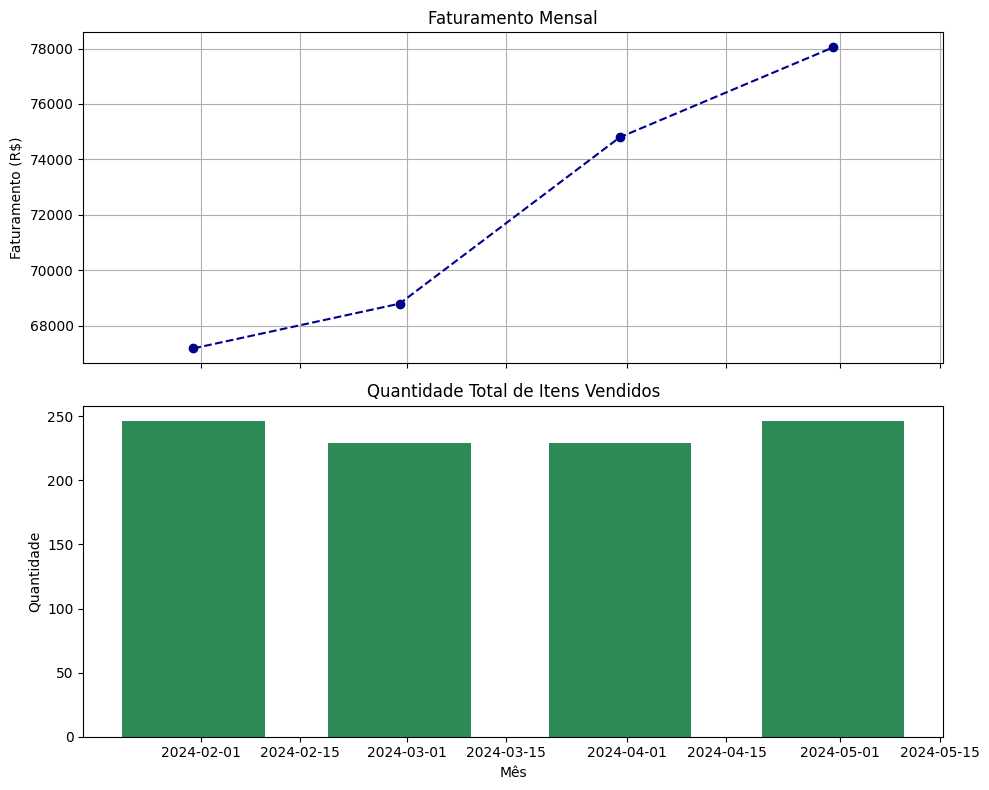

In [ ]:
quantidade_mensal = df.set_index('data')['quantidade'].resample('ME').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

ax1.plot(faturamento_mensal.index, faturamento_mensal.values, marker='o', linestyle='--', color='darkblue')
ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True)

ax2.bar(quantidade_mensal.index, quantidade_mensal.values, width=20, color='seagreen')
ax2.set_title('Quantidade Total de Itens Vendidos')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

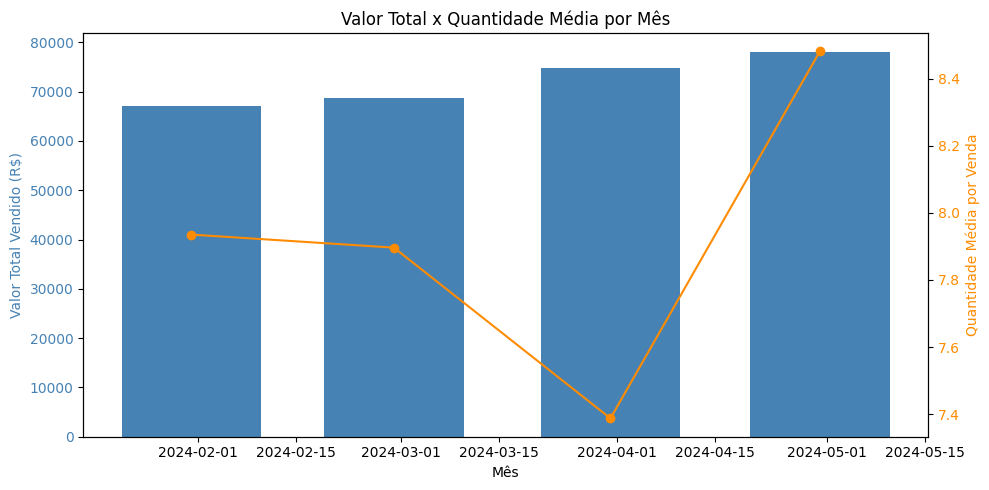

In [ ]:
qtd_media_mensal = df.set_index('data')['quantidade'].resample('ME').mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(faturamento_mensal.index, faturamento_mensal.values, width=20, color='steelblue', label='Valor total (R$)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total Vendido (R$)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(qtd_media_mensal.index, qtd_media_mensal.values, marker='o', color='darkorange', label='Qtd média/venda')
ax2.set_ylabel('Quantidade Média por Venda', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Valor Total x Quantidade Média por Mês')
plt.tight_layout()
plt.show()

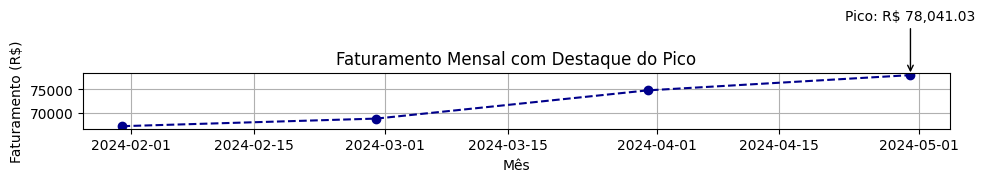

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(faturamento_mensal.index, faturamento_mensal.values, marker='o', linestyle='--', color='darkblue')

mes_pico = faturamento_mensal.idxmax()
valor_pico = faturamento_mensal.max()

ax.annotate(
    f'Pico: R$ {valor_pico:,.2f}',
    xy=(mes_pico, valor_pico),
    xytext=(mes_pico, valor_pico * 1.15),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    ha='center'
)
ax.set_title('Faturamento Mensal com Destaque do Pico')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True)
plt.tight_layout()
plt.show()

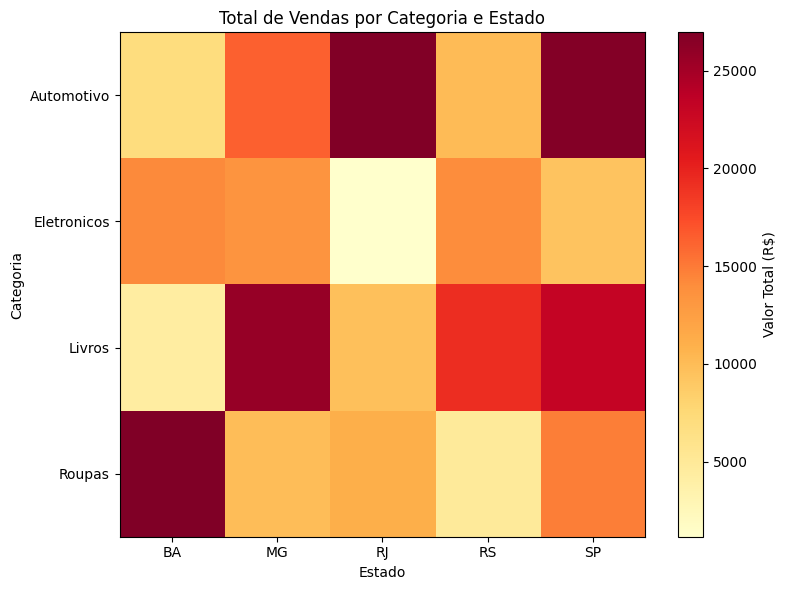

In [ ]:
pivot = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title('Total de Vendas por Categoria e Estado')
ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')

plt.colorbar(im, ax=ax, label='Valor Total (R$)')
plt.tight_layout()
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
plt.show()